In [1]:
import torch
import math
from pyDOE import lhs   # or scipy.stats.qmc.LatinHypercube
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt
from tqdm import trange
import gc
import logging
from torch.func import jacrev, vmap, hessian, jacfwd
from torch.utils.data import TensorDataset, DataLoader
import random
import scipy.io
import torch.nn.init as init
logging.getLogger("torch").setLevel(logging.ERROR)
np.random.seed(1234)
torch.manual_seed(1234)
device = torch.device('cuda:2')

In [2]:
class DeepMLP(nn.Module):
    """Reparameterized MLP used for each one-dimensional subnetwork."""

    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()
        self.activation = activation

        weights, biases = [], []

        for idx in range(1, len(layer_sizes) - 1):
            in_dim, out_dim = layer_sizes[idx - 1], layer_sizes[idx]

            if idx == 1:
                # RepNN first-layer initialization
                weights.append(nn.Parameter(torch.randn(1, out_dim) * 10.0))
                biases.append(nn.Parameter(torch.empty(in_dim, out_dim).uniform_(-1.0, 1.0)))
            else:
                weights.append(nn.Parameter(torch.randn(in_dim, out_dim)))
                biases.append(nn.Parameter(torch.zeros(1, out_dim)))

        # Output-layer initialization
        std = (1.0 / layer_sizes[-2]) ** 0.5
        w = nn.Parameter(torch.randn(layer_sizes[-2], layer_sizes[-1]) * std)
        weights.append(w)
        
        biases.append(nn.Parameter(torch.zeros(1, layer_sizes[-1])))

        self.W = nn.ParameterList(weights)
        self.b = nn.ParameterList(biases)

    def forward(self, x, x_min, x_max):

        # Normalize the input domain to [-1, 1]
        A = 2.0 * (x - x_min) / (x_max - x_min) - 1.0

        for i in range(len(self.W) - 1):
            if i == 0:
                # Reparameterized first layer: W * (x - b)
                A = self.activation(A @ self.W[i] - self.W[i] * self.b[i])
            else:
                A = self.activation(A @ self.W[i] + self.b[i])

        y = A @ self.W[-1] + self.b[-1]

        return y

In [3]:
class Separable2DNet(nn.Module):
    """Separable 2D network with independent RepNN branches for x and y."""

    def __init__(self, layer_sizes, activation=torch.tanh):
        super().__init__()

        # Independent 1D RepNN branches for each spatial coordinate
        self.branch_x = DeepMLP(layer_sizes, activation=activation)
        self.branch_y = DeepMLP(layer_sizes, activation=activation)

        # Linear projection of the tensor-product features
        self.final_linear = nn.Linear(layer_sizes[-1], 1)
        std = (1.0 / layer_sizes[-1]) ** 0.5
        init.normal_(self.final_linear.weight, mean=0.0, std=std)
        init.zeros_(self.final_linear.bias)

        # Default computational domain: [-1, 1]^2
        mins = -torch.ones(2, 1)
        maxs =  torch.ones(2, 1)
        self.register_buffer("mins", mins)
        self.register_buffer("maxs", maxs)

    def set_bounds(self, mins, maxs):
        """Update the spatial bounds used for input normalization."""
        self.mins.copy_(mins)
        self.maxs.copy_(maxs)

    def forward(self, X_star):
        x, y = X_star[:, 0:1], X_star[:, 1:2]

        # Extract coordinate-wise features
        y_pred_x = self.branch_x(x, self.mins[0:1], self.maxs[0:1])
        y_pred_y = self.branch_y(y, self.mins[1:2], self.maxs[1:2])

        # Tensor-product feature representation
        outer_product = y_pred_x * y_pred_y

        y_pred = self.final_linear(outer_product)

        return y_pred

In [4]:
def u_target(t, x):
    freq = 30
    return torch.sin(freq *  math.pi * t /(1+ 9 *x**2)) 

# def u_target(t, x):
#     freq = 10
#     return torch.sin(freq * math.pi * (t + x + t*x))



axis = torch.linspace(-1.0, 1.0, 100).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

layers = [1] + [300] * 5
model = Separable2DNet(layers).to(device)

mins = torch.tensor([[-1.0], [-1.0]], device=device)
maxs = torch.tensor([[1.0], [1.0]], device=device)
model.set_bounds(mins, maxs)

In [5]:
with torch.no_grad():
    y_pred = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

cube_ref = y_ref.view(len(axis), len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis)).cpu().numpy()

Error(L2): 1.50794e+00


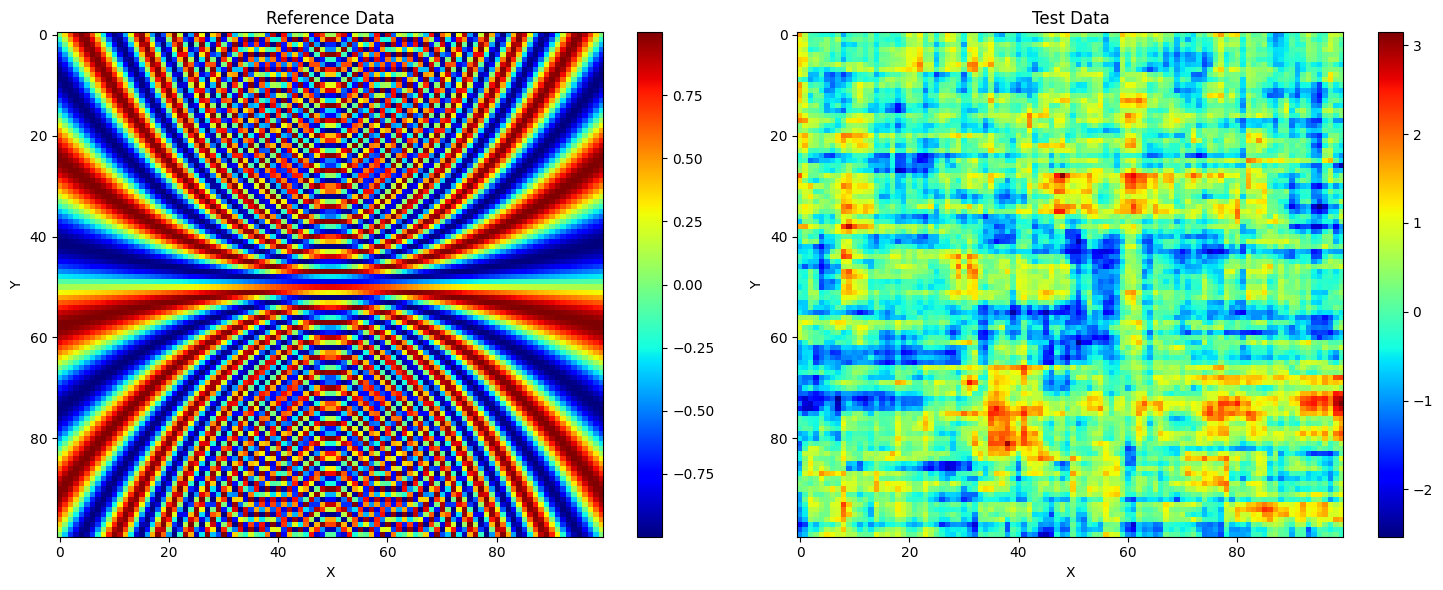

In [6]:
# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 绘制参考数据
im1 = ax1.imshow(cube_ref, cmap='jet', aspect='auto')
ax1.set_title('Reference Data')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
plt.colorbar(im1, ax=ax1)

# 绘制测试数据
im2 = ax2.imshow(cube_test, cmap='jet', aspect='auto')
ax2.set_title('Test Data')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

In [7]:
criterion = nn.MSELoss()
initial_lr = 1.0e-3
alpha = 1e-7 / 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50000, eta_min=initial_lr * alpha)

In [8]:
loss_history = []

nmax = 50000
N_f  = 4096

start_start_time = time.time()
start_start_time_record = time.time()
for n in range(1, nmax + 1):


    lhs_samples = lhs(2, N_f) * 2-1
    X_f = torch.tensor(lhs_samples, dtype=torch.float32, device=device)
    y_batch = u_target(X_f[:, 0:1], X_f[:, 1:2])

    optimizer.zero_grad()
    y_pred = model(X_f)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if n % 1000 == 0:
        bx_mean = model.branch_x.b[0].mean().item()
        by_mean = model.branch_y.b[0].mean().item()
        print(f"n: {n}, loss: {loss.item():.3e},time: {int(time.time() - start_start_time)}")
        loss_history.append(loss.item())
        start_start_time = time.time()

n: 1000, loss: 8.566e-03,time: 6
n: 2000, loss: 6.266e-03,time: 6
n: 3000, loss: 5.387e-03,time: 6
n: 4000, loss: 5.015e-03,time: 6
n: 5000, loss: 4.462e-03,time: 6
n: 6000, loss: 4.082e-03,time: 6
n: 7000, loss: 3.554e-03,time: 6
n: 8000, loss: 3.821e-03,time: 6
n: 9000, loss: 2.795e-03,time: 6
n: 10000, loss: 2.914e-03,time: 6
n: 11000, loss: 2.903e-03,time: 5
n: 12000, loss: 2.510e-03,time: 6
n: 13000, loss: 2.299e-03,time: 6
n: 14000, loss: 2.051e-03,time: 5
n: 15000, loss: 1.946e-03,time: 6
n: 16000, loss: 1.784e-03,time: 5
n: 17000, loss: 1.829e-03,time: 6
n: 18000, loss: 1.503e-03,time: 6
n: 19000, loss: 1.600e-03,time: 6
n: 20000, loss: 1.504e-03,time: 6
n: 21000, loss: 1.224e-03,time: 6
n: 22000, loss: 1.143e-03,time: 6
n: 23000, loss: 1.039e-03,time: 6
n: 24000, loss: 1.011e-03,time: 6
n: 25000, loss: 8.181e-04,time: 6
n: 26000, loss: 8.280e-04,time: 6
n: 27000, loss: 7.739e-04,time: 6
n: 28000, loss: 7.395e-04,time: 6
n: 29000, loss: 5.838e-04,time: 6
n: 30000, loss: 6.030e-

In [9]:
start_start_time_record - time.time()

-302.9745533466339

In [10]:
axis = torch.linspace(-1.0, 1.0, 1000).unsqueeze(1)
axis_t = torch.linspace(-1.0,1.0, 1000).unsqueeze(1)
X, Y = torch.meshgrid(axis_t.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

cube_ref = y_ref.view(len(axis), len(axis)).cpu().numpy()
cube_test = y_test.view(len(axis), len(axis)).cpu().numpy()

Error(L2): 1.84182e-02


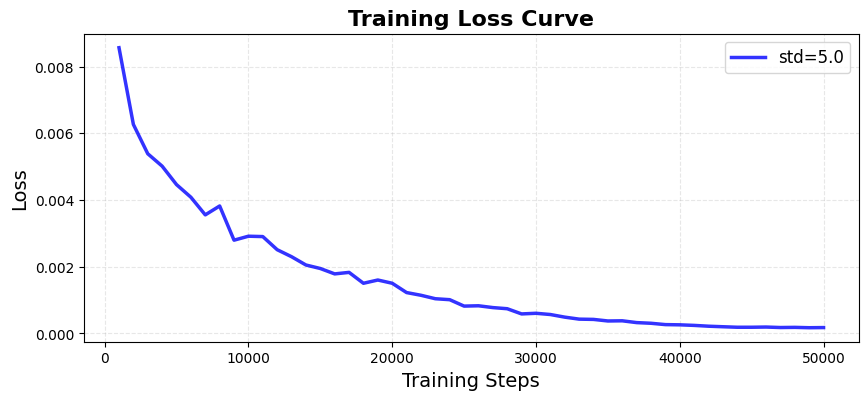

In [11]:
steps = [(i + 1) * 1000 for i in range(len(loss_history))]

plt.figure(figsize=(10, 4))
plt.plot(steps, loss_history, "b-", linewidth=2.5, alpha=0.8, label="std=5.0")

if max(loss_history) / min(loss_history) > 100:
    plt.yscale("log")
    ylabel = "Loss (log scale)"
else:
    ylabel = "Loss"

plt.xlabel("Training Steps", fontsize=14)
plt.ylabel(ylabel, fontsize=14)
plt.title("Training Loss Curve", fontsize=16, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(fontsize=12)
plt.show()


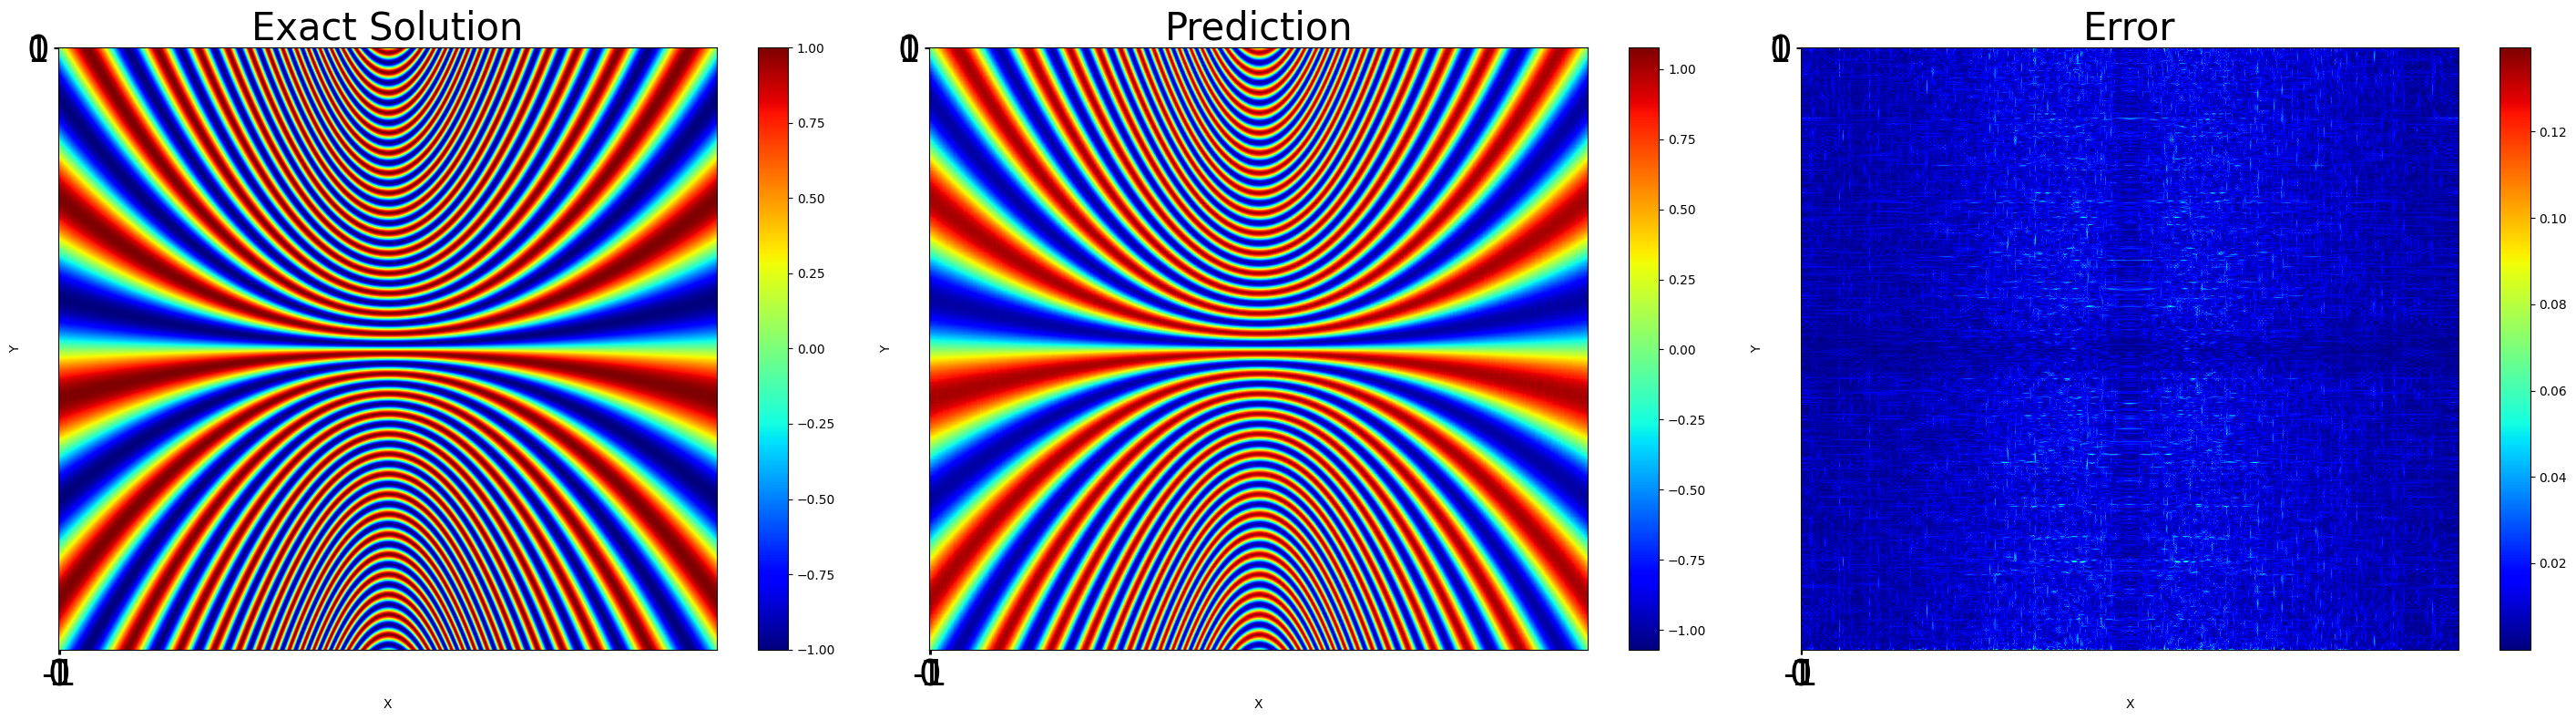

In [12]:
# 创建子图
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(29, 8))

# 绘制参考数据
im1 = ax1.imshow(cube_ref, cmap='jet', aspect='auto')
ax1.set_title('Exact Solution',fontsize=30)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_xticks([-1,0,1])
ax1.set_yticks([0,1])
ax1.set_xticklabels([-1,0,1], fontsize=28)
ax1.set_yticklabels([0,1], fontsize=28)
plt.colorbar(im1, ax=ax1)

# 绘制测试数据
im2 = ax2.imshow(cube_test, cmap='jet', aspect='auto')
ax2.set_title('Prediction',fontsize=30)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_xticks([-1,0,1])
ax2.set_yticks([0,1])
ax2.set_xticklabels([-1,0,1], fontsize=28)
ax2.set_yticklabels([0,1], fontsize=28)
plt.colorbar(im2, ax=ax2)

# 绘制测试数据
im2 = ax3.imshow(np.abs(cube_test-cube_ref), cmap='jet', aspect='auto')
ax3.set_title('Error',fontsize=30)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_xticks([-1,0,1])
ax3.set_yticks([0,1])
ax3.set_xticklabels([-1,0,1], fontsize=28)
ax3.set_yticklabels([0,1], fontsize=28)
plt.colorbar(im2, ax=ax3)

plt.tight_layout()
plt.show()

In [13]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from matplotlib.path import Path
import time
import matplotlib.pyplot as plt
from tqdm import trange
import gc
import logging
from torch.func import jacrev, vmap, hessian, jacfwd
from torch.utils.data import TensorDataset, DataLoader
import random
import math
from scipy.io import loadmat
import matplotlib.tri as tri
logging.getLogger("torch").setLevel(logging.ERROR)
random_seed=1240
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.set_float32_matmul_precision('medium')
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [14]:
U_star = cube_ref.reshape((1000,1000))
U_pred = cube_test.reshape((1000,1000))

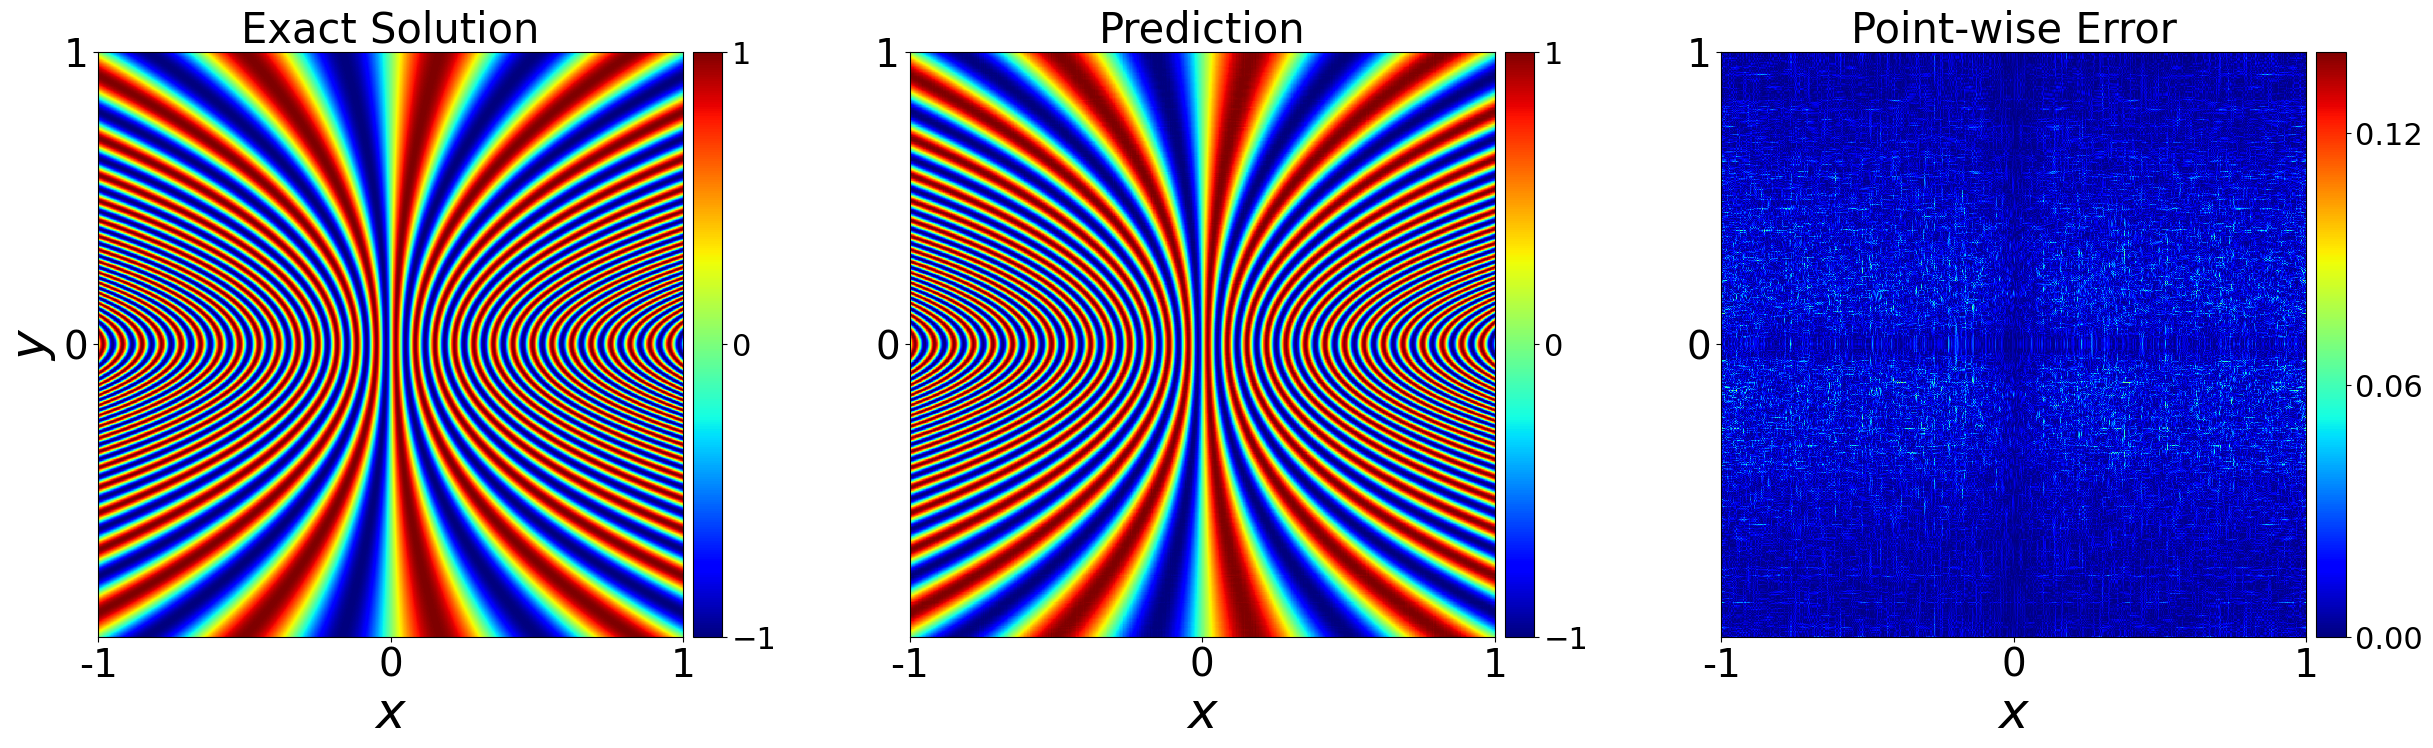

In [15]:
lb = np.array([-1, -1])
ub = np.array([1, 1])

fig, axs = plt.subplots(1, 3, figsize=(29, 8))
fig.subplots_adjust(wspace=0.3)  # 调整子图之间的水平间距

ax2 = axs[0]    
h = ax2.imshow(U_star.T, interpolation='nearest', cmap='jet', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='1',vmin=-1,vmax=1)
ax2.set_title('Exact Solution', fontsize=30)
ax2.set_xlabel('$x$', fontsize=36)
ax2.set_ylabel('$y$', fontsize=36)
ax2.set_xticks([-1,0,1])
ax2.set_yticks([0,1])
ax2.set_xticklabels([-1,0,1], fontsize=28)
ax2.set_yticklabels([0,1], fontsize=28)
#左边的色差图
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(h, cax=cax)  
cbar.set_ticks([-1,0,1.0])
cbar.ax.tick_params(labelsize=22)   


# 第一个子图
ax1 = axs[1]    
h = ax1.imshow(U_pred.T, interpolation='nearest', cmap='jet', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='1',vmin=-1,vmax=1)
ax1.set_title(r'Prediction', fontsize=30)
ax1.set_xlabel('$x$', fontsize=36)
ax1.set_xticks([-1,0,1])
ax1.set_yticks([0,1])
ax1.set_xticklabels([-1,0,1], fontsize=28)
ax1.set_yticklabels([0,1], fontsize=28)
#左边的色差图
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(h, cax=cax)  
cbar.set_ticks([-1,0,1.0])
cbar.ax.tick_params(labelsize=22)   
    

ax3 = axs[2]    
h = ax3.imshow(np.abs(U_star.T-U_pred.T), interpolation='nearest', cmap='jet', 
              extent=[lb[1], ub[1], lb[0], ub[0]], 
              origin='lower', aspect='1',vmin=0,vmax=(np.abs(U_pred-U_star).max()))
ax3.set_title(r'Point-wise Error', fontsize=30)
ax3.set_xlabel('$x$', fontsize=36)
ax3.set_xticks([-1,0,1])
ax3.set_yticks([0,1])
ax3.set_xticklabels([-1,0,1], fontsize=28)
ax3.set_yticklabels([0,1], fontsize=28)
#左边的色差图
divider = make_axes_locatable(ax3)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(h, cax=cax)  
# cbar.set_ticks([0.00001,0.00007,0.00013])
# cbar.ax.tick_params(labelsize=22)  

ticks = [0, 0.06, 0.12]
cbar.set_ticks(ticks)


cbar.ax.tick_params(labelsize=22)  

plt.show() 

In [16]:
X_star = lhs(2, 10000) * 2 -1
X_star = torch.tensor(X_star, dtype=torch.float32, device=device)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred = model(X_star.to(device))

y_test = y_pred.view(-1, 1)
y_ref = targets.view(-1, 1).to(device)

err = torch.linalg.norm(y_test - y_ref) / torch.linalg.norm(y_ref)
print(f"Error(L2): {err:.5e}")

Error(L2): 1.86360e-02


In [17]:
axis = torch.linspace(-1.0, 1.0, 1000).unsqueeze(1)
X, Y = torch.meshgrid(axis.squeeze(), axis.squeeze(), indexing="ij")
X_star = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

targets = u_target(X_star[:, 0:1], X_star[:, 1:2])

with torch.no_grad():
    y_pred = model(X_star.to(device))

y_test = y_pred.view(-1, 1).cpu().numpy()
y_ref = targets.view(-1, 1).to(device).cpu().numpy()

scipy.io.savemat("y_pre.mat", {'u': y_test}) 
scipy.io.savemat("y_ref.mat", {'u': y_ref}) 